In [2]:
print("Alhamdullilah")

Alhamdullilah


#### Wholesale Customers (Scaling, Silhoutte)

1. Raw Data
2. Feature Selection
3. Baseline K-Means
4. Scaling
5. K-Means
6. Silhouette analysis
7. Choose K
8. Final Cluster
9. Interpret

In [7]:
# Load data
import pandas as pd

df = pd.read_csv("data/Wholesale_customers_data.csv")

print(df.info())
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB
None
(440, 8)
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: 

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# features = np.array(df.columns)
features = [
    'Fresh',
    'Milk',
    'Grocery',
    'Frozen',
    'Detergents_Paper',
    'Delicassen'
]

X = df[features]

silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    silhouette_scores.append((k, score))

print(silhouette_scores)

[(2, 0.5115333898779053), (3, 0.4783511430782059), (4, 0.39012913652631787), (5, 0.3832957525216624), (6, 0.3902964439897624), (7, 0.3296780828495873), (8, 0.3335624462567665)]


In [25]:
scaled_silhouette_scores = []
for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scaled_silhouette_scores.append((k, score))

    print(f"k={k}, silhouette={score:.4f}")

# print(scaled_silhouette_scores)

k=2, silhouette=0.5472
k=3, silhouette=0.5483
k=4, silhouette=0.3485
k=5, silhouette=0.3690
k=6, silhouette=0.3782
k=7, silhouette=0.3343
k=8, silhouette=0.3201


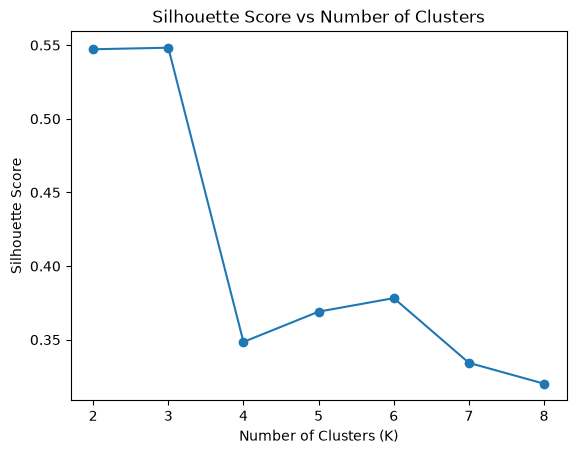

In [26]:
import matplotlib.pyplot as plt

k_values = range(2, 9)
scores = [score for k, score in scaled_silhouette_scores]

plt.plot(k_values, scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.xticks(k_values)
plt.show()

In [29]:
from sklearn.cluster import KMeans

final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = final_kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

df['Cluster'].value_counts().sort_index()

final_score = silhouette_score(
    X_scaled,
    df['Cluster']
)

print(f"Final silhouette score: {final_score:.4f}")

Final silhouette score: 0.5483


In [32]:
cluster_profile = df.groupby('Cluster')[features].mean().round(0)

cluster_profile

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,10441.0,19386.0,28656.0,2190.0,13328.0,2374.0
1,12063.0,4115.0,5535.0,2941.0,1696.0,1299.0
2,34782.0,30367.0,16898.0,48702.0,756.0,26776.0


In [38]:
cluster_size = df['Cluster'].value_counts().sort_index()
cluster_profile['Customers'] = df['Cluster'].value_counts().sort_index()
cluster_percentage = df['Cluster'].value_counts(normalize=True).sort_index().mul(100).round(2)
cluster_profile['Percentage'] = cluster_percentage

cluster_profile

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Customers,Percentage
Cluster,,,,,,,,
0,10441.0,19386.0,28656.0,2190.0,13328.0,2374.0,45,10.23
1,12063.0,4115.0,5535.0,2941.0,1696.0,1299.0,393,89.32
2,34782.0,30367.0,16898.0,48702.0,756.0,26776.0,2,0.45


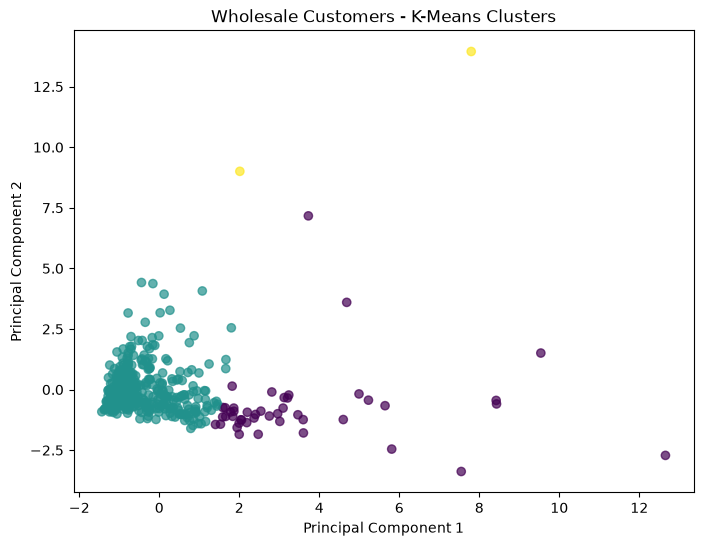

In [43]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['Cluster'],
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wholesale Customers - K-Means Clusters")

plt.show()

In [44]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.44082893 0.283764  ]
0.7245929240774496


In [53]:
relative_profile = cluster_profile/df[features].mean().round(0)
relative_profile.T

Cluster,0,1,2
Customers,NaN,NaN,NaN
Delicassen,1.556721,0.851803,17.558033
Detergents_Paper,4.626171,0.588684,0.262409
Fresh,0.870083,1.005250,2.898500
Frozen,0.712891,0.957357,15.853516
Grocery,3.604075,0.696139,2.125267
Milk,3.344720,0.709972,5.239303
Percentage,NaN,NaN,NaN
